In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

In [3]:
from pathlib import Path
from openpi.shared import download

import flax.traverse_util as traverse_util
import jax
from jax.sharding import SingleDeviceSharding

from openpi.models import model as openpi_model


def load_and_list_param_names(params_dir: str, training_gpu_rank: int = 0):
    # Pick one device so params are not replicated.
    try:
        gpus = jax.devices("gpu")
    except RuntimeError:
        gpus = []
    if gpus:
        idx = min(max(training_gpu_rank, 0), len(gpus) - 1)
        device = gpus[idx]
    else:
        device = jax.devices()[0]

    sharding = SingleDeviceSharding(device)
    params = openpi_model.restore_params(Path(params_dir), sharding=sharding)

    flat = traverse_util.flatten_dict(params, sep="/")
    print(f"Loaded {len(flat)} parameter leaves on {device}\n")
    for name in sorted(flat.keys()):
        arr = flat[name]
        print(f"{name:120s} shape={tuple(arr.shape)} dtype={arr.dtype}")

    return params


# Example:
# params = load_and_list_param_names("/path/to/checkpoint/params", training_gpu_rank=0)

In [4]:
checkpoint_path = "gs://cat-logs/pi05_steervla_cot_simplified_reasoning/pi05_steervla_cot_simplified_reasoning/pi05_steervla_cot_simplified_reasoning_20260523_135610/2000"
checkpoint_dir = download.maybe_download(checkpoint_path)

In [5]:
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "true"
# os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"
# export XLA_PYTHON_CLIENT_PREALLOCATE=false
# export XLA_PYTHON_CLIENT_ALLOCATOR=platform

In [6]:
import dataclasses

import jax

from openpi.models import model as _model
from openpi.policies import steervla_policy
from openpi.policies import policy_config as _policy_config
from openpi.shared import download
from openpi.training import config as _config
from openpi.training import data_loader as _data_loader
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [7]:
# Load the model 
config = _config.get_config("pi05_steervla_cot_simplified_reasoning")
# checkpoint_path = "gs://cat-logs/pi05_steervla_cot_ki/pi05_steervla_cot_ki/90000"
# checkpoint_dir = download.maybe_download(checkpoint_path)

In [8]:
policy = _policy_config.create_trained_policy(config, checkpoint_dir)

In [9]:
jax.devices()

[CudaDevice(id=0), CudaDevice(id=1)]

In [81]:
example = steervla_policy.make_steervla_example()
cot_sample_kwargs = {"image_keys": ["base_0_rgb"]}
# result = policy.infer_with_cot(example)

In [82]:
print(example)

{'observation/image': array([[[228, 199, 188],
        [ 68,  39,  73],
        [188, 168, 220],
        ...,
        [ 52, 165, 203],
        [ 93,   7, 234],
        [207, 118, 149]],

       [[184, 146, 182],
        [ 91, 159, 110],
        [107,  75, 167],
        ...,
        [241, 238,  75],
        [212,   1, 247],
        [126, 132,  35]],

       [[248,  11, 102],
        [ 12, 103, 141],
        [203,  78, 231],
        ...,
        [ 62, 193, 166],
        [110, 152, 143],
        [ 47, 211,  21]],

       ...,

       [[194,  60, 142],
        [ 26, 162, 194],
        [  9, 164, 100],
        ...,
        [249, 244, 118],
        [ 42, 239, 204],
        [  1, 186, 131]],

       [[149, 116, 160],
        [167, 233,  52],
        [128, 102,  20],
        ...,
        [248, 168, 230],
        [ 36, 132, 230],
        [206, 162,  90]],

       [[ 81, 131,  11],
        [ 42, 185,  24],
        [122,  24,  75],
        ...,
        [ 75, 127, 209],
        [ 63, 110, 232],
  

In [83]:
example["subtask"] = "The vehicle decelerates with a slight left adjustment."
example["reasoning"] = "Follow the route."
example["prompt"] = "Prompt:The current speed is 10 m/s.follow the route.;State: 131 102;"
# example["observation/image"] = Image.open("/home/carla/outputs/image.png")

In [ ]:
example.keys()

In [13]:
import jax.numpy as jnp
import time
import numpy as np

In [ ]:
plt.imshow(example["observation/image"])
plt.show()

In [85]:
inputs = jax.tree.map(lambda x: x, example)
# inputs = policy._input_transform(inputs)
# inputs = jax.tree.map(lambda x: jnp.asarray(x)[np.newaxis, ...], inputs)
policy._rng, rng_cot, rng_act = jax.random.split(policy._rng, 3)

# sample_kwargs = dict(policy._sample_kwargs)

# observation = _model.Observation.from_dict(inputs)

In [86]:
t_cot = time.monotonic()
result_slow = policy.infer(inputs)
cot_ms = (time.monotonic() - t_cot) * 1000

In [87]:
result_slow

{'actions': array([[ 0.31555831, -0.00959806,  0.99951824, -0.02242631],
        [ 0.31752204, -0.01526796,  1.00095952, -0.02510343],
        [ 0.29868138, -0.02217164,  0.99718951, -0.04980415],
        [ 0.26858968, -0.03393844,  0.99210294, -0.10006856],
        [ 0.2460609 , -0.05184926,  0.98825292, -0.14622094],
        [ 0.27081295, -0.07762471,  0.98459549, -0.16926207],
        [ 0.28252854, -0.09347262,  0.98144835, -0.19208195],
        [ 0.27355941, -0.09424955,  0.97569932, -0.20603724],
        [ 0.26087499, -0.09175068,  0.96767051, -0.24189302],
        [ 0.23659084, -0.09053604,  0.95763094, -0.27479438]]),
 'policy_timing': {'infer_ms': 70.11845201486722}}

In [88]:
# Plot the actions
from openpi.visualizing.steervla_visualization import denormalize_actions, compute_waypoints
import matplotlib.pyplot as plt

In [89]:
actions = result_slow["actions"]

In [26]:
actions.shape

(10, 4)

In [19]:
%matplotlib inline

[[ 2.20890815 -0.06718645  0.99951824 -0.02242631]
 [ 2.2226543  -0.10687574  1.00095952 -0.02510343]
 [ 2.09076969 -0.15520147  0.99718951 -0.04980415]
 [ 1.88012775 -0.23756906  0.99210294 -0.10006856]
 [ 1.72242629 -0.36294481  0.98825292 -0.14622094]
 [ 1.89569067 -0.54337297  0.98459549 -0.16926207]
 [ 1.97769976 -0.65430831  0.98144835 -0.19208195]
 [ 1.9149159  -0.65974684  0.97569932 -0.20603724]
 [ 1.82612496 -0.64225475  0.96767051 -0.24189302]
 [ 1.6561359  -0.63375226  0.95763094 -0.27479438]]


<module 'matplotlib.pyplot' from '/home/carla/ogbench-carla/.venv/lib/python3.11/site-packages/matplotlib/pyplot.py'>

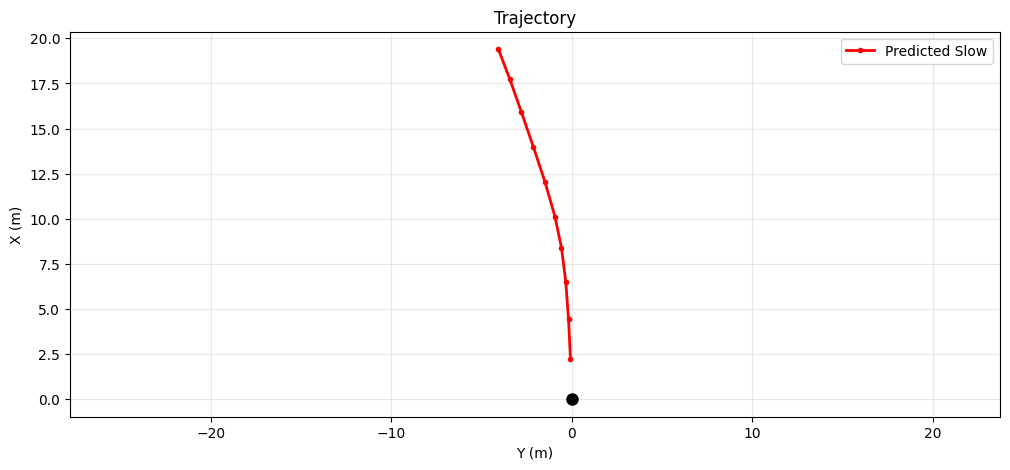

In [90]:
output_action_format = "delta_xy_t_delta_xy_space"
initial_speeds = jnp.ones_like(actions[..., 0]) * 10.0
dt = 0.1
# pred_denorm = denormalize_actions(result, 4, output_action_format)
# pred_wp = compute_waypoints(pred_denorm, initial_speeds, dt, output_action_format)
pred_denorm_slow = denormalize_actions(actions, 4, output_action_format)
print(pred_denorm_slow)
pred_wp_slow = compute_waypoints(pred_denorm_slow, initial_speeds, dt, output_action_format)

# pred_denorm_left = denormalize_actions(result_left, 4, output_action_format)
# pred_wp_left = compute_waypoints(pred_denorm_left, initial_speeds, dt, output_action_format)

# pred_denorm_right = denormalize_actions(result_right, 4, output_action_format)
# pred_wp_right = compute_waypoints(pred_denorm_right, initial_speeds, dt, output_action_format)

fig, axes = plt.subplots(1, 1, figsize=(12, 5))

ax = axes

# ax.plot(
#     pred_wp[0, :, 1], pred_wp[0, :, 0],
#     "b.--", label="Predicted", linewidth=2,
# )
ax.plot(
    pred_wp_slow[:, 1], pred_wp_slow[:, 0],
    "r.-", label="Predicted Slow", linewidth=2,
)
# ax.plot(
#     pred_wp_left[0, :, 1], pred_wp_left[0, :, 0],
#     "g.-", label="Predicted Left", linewidth=2,
# )
# ax.plot(
#     pred_wp_right[0, :, 1], pred_wp_right[0, :, 0],
#     "y.-", label="Predicted Right", linewidth=2,
# )
ax.plot(0, 0, "ko", markersize=8)
ax.set_xlabel("Y (m)")
ax.set_ylabel("X (m)")
ax.set_title(f"Trajectory")
ax.legend()
ax.grid(True, alpha=0.3)
ax.axis("equal")
plt

In [ ]:
# Now load examples from the dataset

config = dataclasses.replace(config, batch_size=8)

# Create a model from the checkpoint.
# model = config.model.load(_model.restore_params(checkpoint_dir / "params"))

In [ ]:
# config = dataclasses.replace(config, data=dataclasses.replace(config.data, hl_dataset_name_weight_mappings={"simplified_reasoning_dataset": 1.0}))
# config = dataclasses.replace(config, data=dataclasses.replace(config.data, dataset_name_weight_mappings={"simlingo_dataset_all_img512_1116": 0.0}))
loader = _data_loader.create_data_loader(config, num_batches=1, skip_norm_stats=True)
obs, act = next(iter(loader))

In [ ]:
obs.tokenized_subtask

In [ ]:
import sentencepiece
import openpi.shared.download as download
import openpi.models.tokenizer as tokenizer

tokenizer = tokenizer.CoTPaligemmaTokenizer()

sp = tokenizer._tokenizer


In [ ]:
import numpy as np
def _decode_tokens(token_ids: np.ndarray, mask: np.ndarray, tokenizer) -> str:
    """Decode a padded token array back to text using the given SP tokenizer."""
    valid = token_ids[mask.astype(bool)]
    return tokenizer.decode(valid.tolist())

In [ ]:
for i in range(8):
    print("Prompt:", _decode_tokens(obs.tokenized_prompt[i], obs.tokenized_prompt_mask[i], tokenizer._tokenizer))
    print("Number of tokens:", len(obs.tokenized_prompt[i]))
    print("Reasoning:", _decode_tokens(obs.tokenized_reasoning[i], obs.tokenized_reasoning_mask[i], tokenizer._tokenizer))
    print("Reasoning orig: ", obs.tokenized_reasoning[i])
    print("Reasoning targets: ", obs.tokenized_reasoning[i][1:])
    print("Number of tokens:", len(obs.tokenized_reasoning[i]))
    print("Subtask:", _decode_tokens(obs.tokenized_subtask[i], obs.tokenized_subtask_mask[i], tokenizer._tokenizer))
    print("Number of tokens:", len(obs.tokenized_subtask[i]))
    print("Action loss mask:", obs.action_loss_mask[i])
    print()

In [ ]:
token = tokenizer.vocab_size - 1 - 128 - 1 
tokenizer.
_decode_tokens(np.array([token]), np.array([True]), tokenizer._tokenizer)

In [ ]:
start_subtask_text = _decode_tokens(np.array([tokenizer._start_of_subtask()]), np.array([True]), tokenizer._tokenizer)
end_subtask_text = _decode_tokens(np.array([tokenizer._end_of_subtask()]), np.array([True]), tokenizer._tokenizer)
start_reasoning_text = _decode_tokens(np.array([tokenizer._start_of_reasoning()]), np.array([True]), tokenizer._tokenizer)
end_reasoning_text = _decode_tokens(np.array([tokenizer._end_of_reasoning()]), np.array([True]), tokenizer._tokenizer)
example_prompt = "Prompt:A car is driving down the street;State:84 116;" + start_subtask_text + "Follow the road normally;" + end_subtask_text + start_reasoning_text + "The car is driving down the street;" + end_reasoning_text
print(example_prompt)
subtask = example_prompt.split(end_subtask_text)[0].split(start_subtask_text)[1]
reasoning = example_prompt.split(end_reasoning_text)[0].split(start_reasoning_text)[1]
print(subtask)
print(reasoning)
print(tokenizer._tokenizer.eos_id())

In [ ]:
string = " blahblahblah"
string.split(";")[0]


In [ ]:
prompt = _decode_tokens(obs.tokenized_prompt[0], obs.tokenized_prompt_mask[0], sp)
subtask = _decode_tokens(obs.tokenized_subtask[0], obs.tokenized_subtask_mask[0], sp)
reasoning = _decode_tokens(obs.tokenized_reasoning[0], obs.tokenized_reasoning_mask[0], sp)

In [ ]:
print("Prompt: ", prompt)
print("Subtask: ", subtask)
print("Reasoning: ", reasoning)


In [ ]:
key = jax.random.key(0)
cot = model.sample_cot(key, obs)

In [ ]:
detokenized_cot = _decode_tokens(cot["tokenized_subtask"][0], cot["tokenized_subtask_mask"][0], sp)

In [ ]:
detokenized_cot

In [ ]:

import logging

import einops
import flax.nnx as nnx
import flax.nnx.bridge as nnx_bridge
import jax
import jax.numpy as jnp
from typing_extensions import override

from openpi.models import model as _model
from openpi.models import pi0
from openpi.models import pi0_config
import openpi.models.gemma as _gemma
import openpi.models.siglip as _siglip
from openpi.shared import array_typing as at

max_subtask_len = 24


observation = _model.preprocess_observation(None, obs, train=False)
if observation.tokenized_prompt is None or observation.tokenized_prompt_mask is None:
    raise ValueError("sample_cot requires tokenized_prompt and tokenized_prompt_mask")

batch_size = observation.state.shape[0]
ms = model.max_subtask_len
mr = model.max_reasoning_len

In [ ]:
print(ms)
print(mr)

In [ ]:
# Embed images
img_tokens, img_masks, img_ar = model._embed_images(observation)
        
# Embed prompt
prompt_emb = model._embed_text_tokens(observation.tokenized_prompt)
prompt_mask = observation.tokenized_prompt_mask
        
# Construct prefix
prefix_tokens = jnp.concatenate(img_tokens + [prompt_emb], axis=1)
prefix_mask = jnp.concatenate(img_masks + [prompt_mask], axis=1)
prefix_ar = jnp.array(img_ar + [False] * prompt_emb.shape[1])
        
# Build attention mask
prefix_attn_mask = pi0.make_attn_mask(prefix_mask, prefix_ar)
positions = jnp.cumsum(prefix_mask, axis=1) - 1

# Prefill prefix
(prefix_out, _), kv_cache = model.PaliGemma.llm(
    [prefix_tokens, None], mask=prefix_attn_mask, positions=positions
)
assert prefix_out is not None

In [ ]:
prefix_tokens[0].shape

In [ ]:
rng = jax.random.key(0)
h = model._gather_last_valid_hidden(prefix_out, prefix_mask)
key_mask = prefix_mask
abs_pos = jnp.sum(prefix_mask, axis=1, keepdims=True).astype(jnp.int32)

# Buffer for subtask
sub_buf = jnp.zeros((batch_size, ms), dtype=jnp.int32)
sub_m = jnp.zeros((batch_size, ms), dtype=jnp.bool_)
rng_cur = rng

In [ ]:
print(_decode_tokens(observation.tokenized_prompt[0], observation.tokenized_prompt_mask[0], sp))

In [ ]:
print(sp.encode("|")[0])

In [ ]:
temperature = 0.9
# Generate subtask
for i in range(ms):
    print("iter: ", i)
    # Decode logits
    logits = model.PaliGemma.llm(h, method="decode_logits")[:, 0, :]
    if temperature and temperature > 0:
        # Temperature sampling
        rng_cur, step_rng = jax.random.split(rng_cur)
        tok = jax.random.categorical(step_rng, logits / jnp.maximum(temperature, 1e-6))
    else:
        # Greedy
        tok = jnp.argmax(logits, axis=-1)
    
    # Update buffer
    sub_buf = sub_buf.at[:, i].set(tok)
    sub_m = sub_m.at[:, i].set(True)
    if i == ms - 1:
        break
    
    # Embed token
    emb = model._embed_text_tokens(tok[:, None])
    key_mask = jnp.concatenate([key_mask, jnp.ones((batch_size, 1), dtype=jnp.bool_)], axis=1)
    attn_mask = key_mask[:, None, :]  # (b, 1, k_len); Module adds head axis
    (out, _), kv_cache = model.PaliGemma.llm(
        [emb, None],
        mask=attn_mask,
        positions=abs_pos,
        kv_cache=kv_cache,
    )
    assert out is not None
    h = out
    abs_pos = abs_pos + 1

In [ ]:
subtask = _decode_tokens(sub_buf[0], sub_m[0], sp)
print(subtask)

In [ ]:
rea_buf = jnp.zeros((batch_size, mr), dtype=jnp.int32)
rea_m = jnp.zeros((batch_size, mr), dtype=jnp.bool_)

for j in range(mr):
    logits = self.PaliGemma.llm(h, method="decode_logits")[:, 0, :]
    if temperature and temperature > 0:
    rng_cur, step_rng = jax.random.split(rng_cur)
    tok = jax.random.categorical(step_rng, logits / jnp.maximum(temperature, 1e-6))
else:
    tok = jnp.argmax(logits, axis=-1)
rea_buf = rea_buf.at[:, j].set(tok)
rea_m = rea_m.at[:, j].set(True)
if j == mr - 1:
    break
emb = self._embed_text_tokens(tok[:, None])
key_mask = jnp.concatenate([key_mask, jnp.ones((batch_size, 1), dtype=jnp.bool_)], axis=1)
attn_mask = key_mask[:, None, :]
(out, _), kv_cache = self.PaliGemma.llm(
    [emb, None],
    mask=attn_mask,
    positions=abs_pos,
    kv_cache=kv_cache,
)
assert out is not None
h = out
abs_pos = abs_pos + 1

In [ ]:
# Now we can sample actions and cot from the model
key = jax.random.key(0)
actions = model.sample_actions(key, obs, num_steps=10)
cot = model.sample_cot(key, obs)

In [ ]:
actions

In [ ]:
cot

In [ ]:
print("Prompt: ", _decode_tokens(obs.tokenized_prompt, obs.tokenized_prompt_mask, sp))

In [ ]:
# Now detokenize the actions and cot


In [ ]:
detokenized_cot